# Direct estimates and sampling variance

**Navigation**: [← Previous: Data Acquisition](02_data_acquisition.ipynb) | [Next: Classical EBLUP →](04_eblup.ipynb)

We inspect $y_i$ and $\psi_i$ directly: where the APS is stable, where it is noise, and how that tracks the economically active population used as a size proxy.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'sae_utils.py').exists():
    PROJ_DIR = Path('projects/small-area-estimation').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from sae_utils import (
    load_panel, modelling_frame, design_matrix, eblup_fh, fh_reml_sigma_u,
    jackknife_mse, gibbs_fh, summarise_theta, posterior_predictive_y,
    rhat_split, coverage_rate, project_data_dir,
)

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

FIG_DIR = PROJ_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = project_data_dir()
PANEL = load_panel()
MODEL = modelling_frame(PANEL)
print(f'Panel: {len(PANEL)} local authorities; modelling subset: {len(MODEL)}')
print(f'Period (APS / ONS model-based): {PANEL["direct_period"].dropna().iloc[0]}')


Panel: 348 local authorities; modelling subset: 136
Period (APS / ONS model-based): Apr 2025-Mar 2026


## The design-based object

$y_i$ is an estimated **percentage** of economically active 16–64 year olds who are ILO unemployed. The Nomis denominator is a **weighted population estimate**, not the APS sample size. CVs therefore need the published CI; you cannot reconstruct $\psi_i$ from $y_i(1-y_i)/N_i^{\mathrm{pop}}$.

A rule of thumb in ONS quality reports is that CVs above ~20% are too volatile for unaided publication. That is exactly the regime Fay–Herriot is designed for.

In [2]:
m = MODEL.copy()
m['size_proxy'] = m['direct_rate_denominator']
print(m[['direct_rate','psi','cv','size_proxy']].describe().round(3).to_string())
print(f"\nShare with CV > 0.20: {(m['cv'] > 0.20).mean():.1%}")
print(f"Share with CV > 0.30: {(m['cv'] > 0.30).mean():.1%}")


       direct_rate      psi       cv  size_proxy
count      136.000  136.000  136.000     136.000
mean         5.515    1.694    0.235  139136.765
std          1.887    1.023    0.044   76972.335
min          1.900    0.315    0.126   27900.000
25%          4.100    1.041    0.204   86675.000
50%          5.200    1.377    0.235  126050.000
75%          6.700    2.189    0.268  171425.000
max         11.700    5.271    0.329  551500.000

Share with CV > 0.20: 75.7%
Share with CV > 0.30: 5.1%


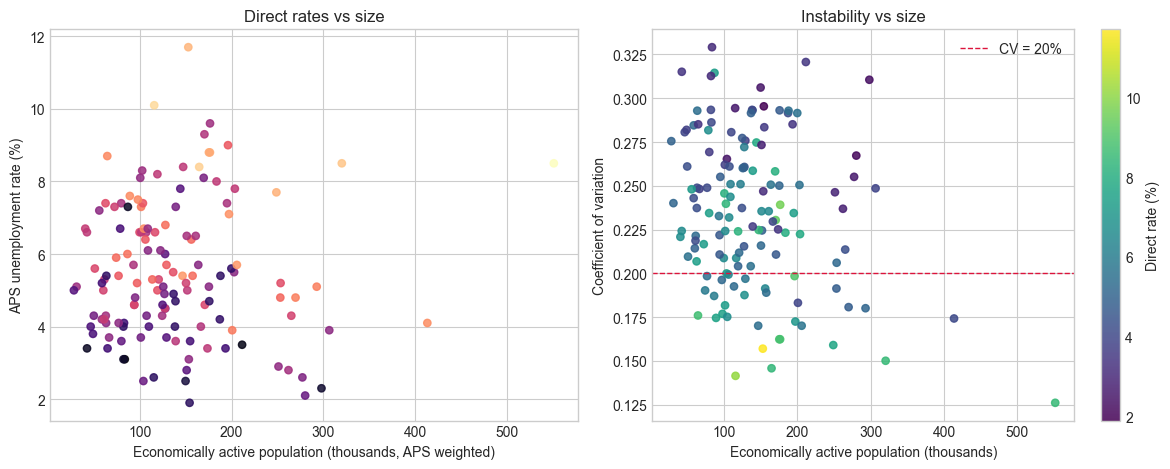

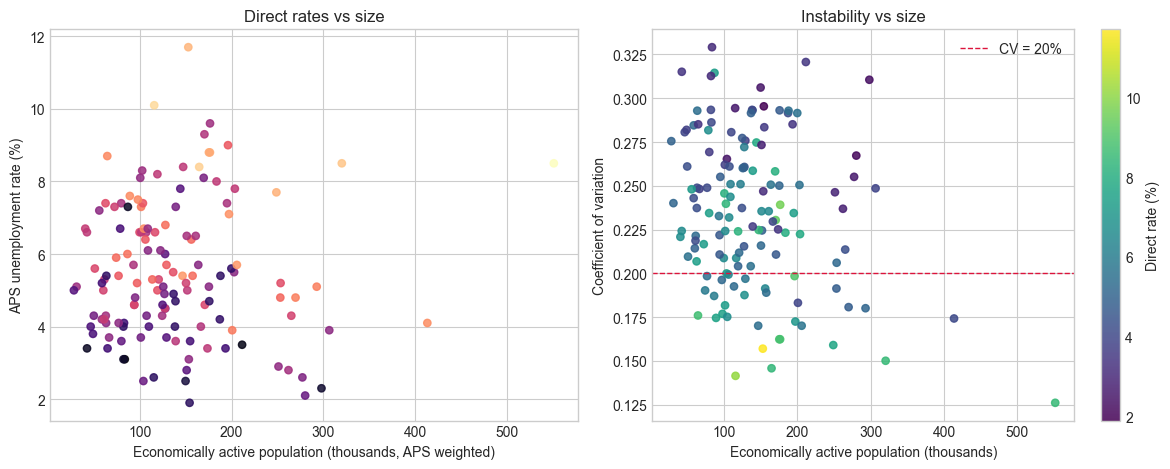

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(m['size_proxy']/1e3, m['direct_rate'], c=m['cv'], cmap='magma_r', s=28, alpha=0.85)
axes[0].set_xlabel('Economically active population (thousands, APS weighted)')
axes[0].set_ylabel('APS unemployment rate (%)')
axes[0].set_title('Direct rates vs size')
sc = axes[1].scatter(m['size_proxy']/1e3, m['cv'], c=m['direct_rate'], cmap='viridis', s=28, alpha=0.85)
axes[1].axhline(0.20, color='crimson', ls='--', lw=1, label='CV = 20%')
axes[1].set_xlabel('Economically active population (thousands)')
axes[1].set_ylabel('Coefficient of variation')
axes[1].set_title('Instability vs size')
axes[1].legend()
fig.colorbar(sc, ax=axes[1], label='Direct rate (%)')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_cv_vs_size.png', dpi=120)
fig


The left panel is the usual heteroskedastic scatter: smaller LAs fan out. The right panel is the diagnostic that matters for SAE — CV declines with size, but even some large authorities sit above 20% because unemployment is rare. Those points will receive $\gamma_i$ well below 1.

In [4]:
fig = px.scatter(
    m, x='size_proxy', y='direct_rate',
    error_y='direct_rate_ci', color='country',
    hover_name='GEOGRAPHY_NAME',
    log_x=True,
    labels={'size_proxy': 'APS economically active (weighted)', 'direct_rate': 'Unemployment rate (%)'},
    title='Direct estimates with published 95% CI half-widths',
)
display_plotly(fig)


## Direct vs claimant count

If the linking model is going to help, $x_i$ must be correlated with $\theta_i$ **after** accounting for the fact that $y_i$ is noisy. A raw scatter of $y_i$ against claimant rate understates the true correlation (attenuation). ONS's production model is betting that the administrative series tracks the ILO concept closely enough for $u_i$ to be small.

corr(claimant, direct) = 0.486
corr(inactivity, direct) = 0.159


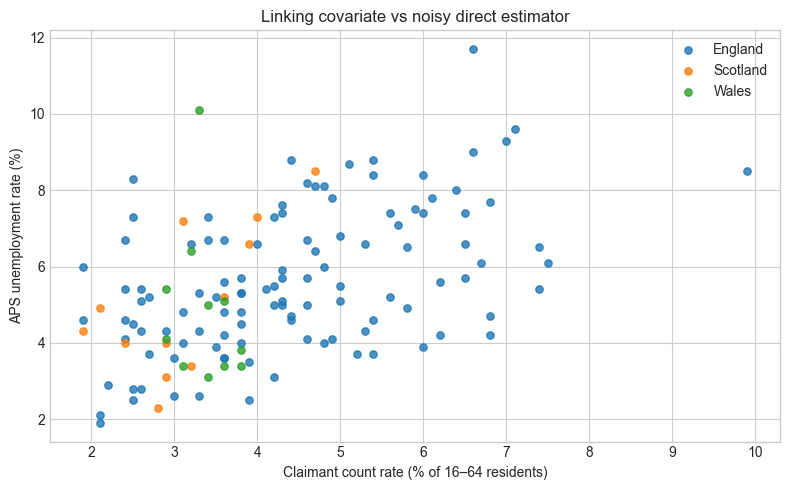

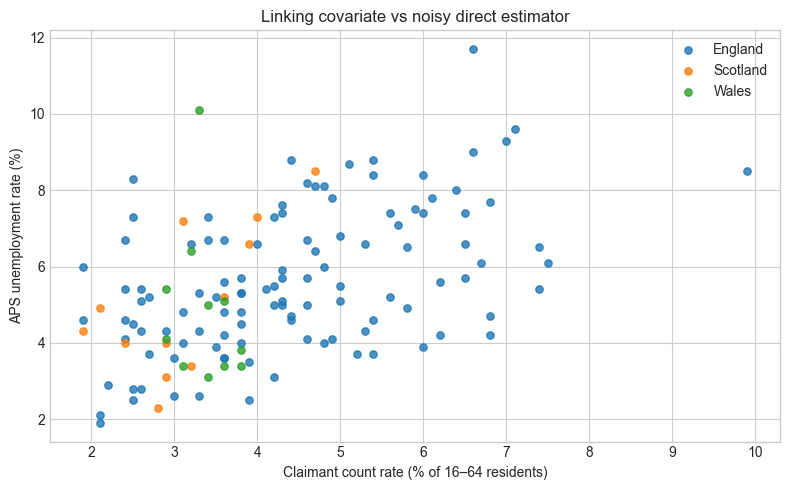

In [5]:
r = np.corrcoef(m['claimant_rate'], m['direct_rate'])[0, 1]
print(f'corr(claimant, direct) = {r:.3f}')
if m['inactivity_rate'].notna().all():
    r2 = np.corrcoef(m['inactivity_rate'], m['direct_rate'])[0, 1]
    print(f'corr(inactivity, direct) = {r2:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
for c, g in m.groupby('country'):
    ax.scatter(g['claimant_rate'], g['direct_rate'], s=28, alpha=0.8, label=c)
ax.set_xlabel('Claimant count rate (% of 16–64 residents)')
ax.set_ylabel('APS unemployment rate (%)')
ax.set_title('Linking covariate vs noisy direct estimator')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '03_claimant_vs_direct.png', dpi=120)
fig


## Key takeaways

- Published CIs, not population denominators, identify $\psi_i$.
- A large share of even the *publishable* LAs have CV > 20%.
- Claimant count co-moves with APS unemployment, which is necessary (not sufficient) for a useful linking model.

---

**Navigation**: [← Previous: Data Acquisition](02_data_acquisition.ipynb) | [Next: Classical EBLUP →](04_eblup.ipynb)
